In [47]:
#importing the libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [48]:
df = pd.read_csv("Housing.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

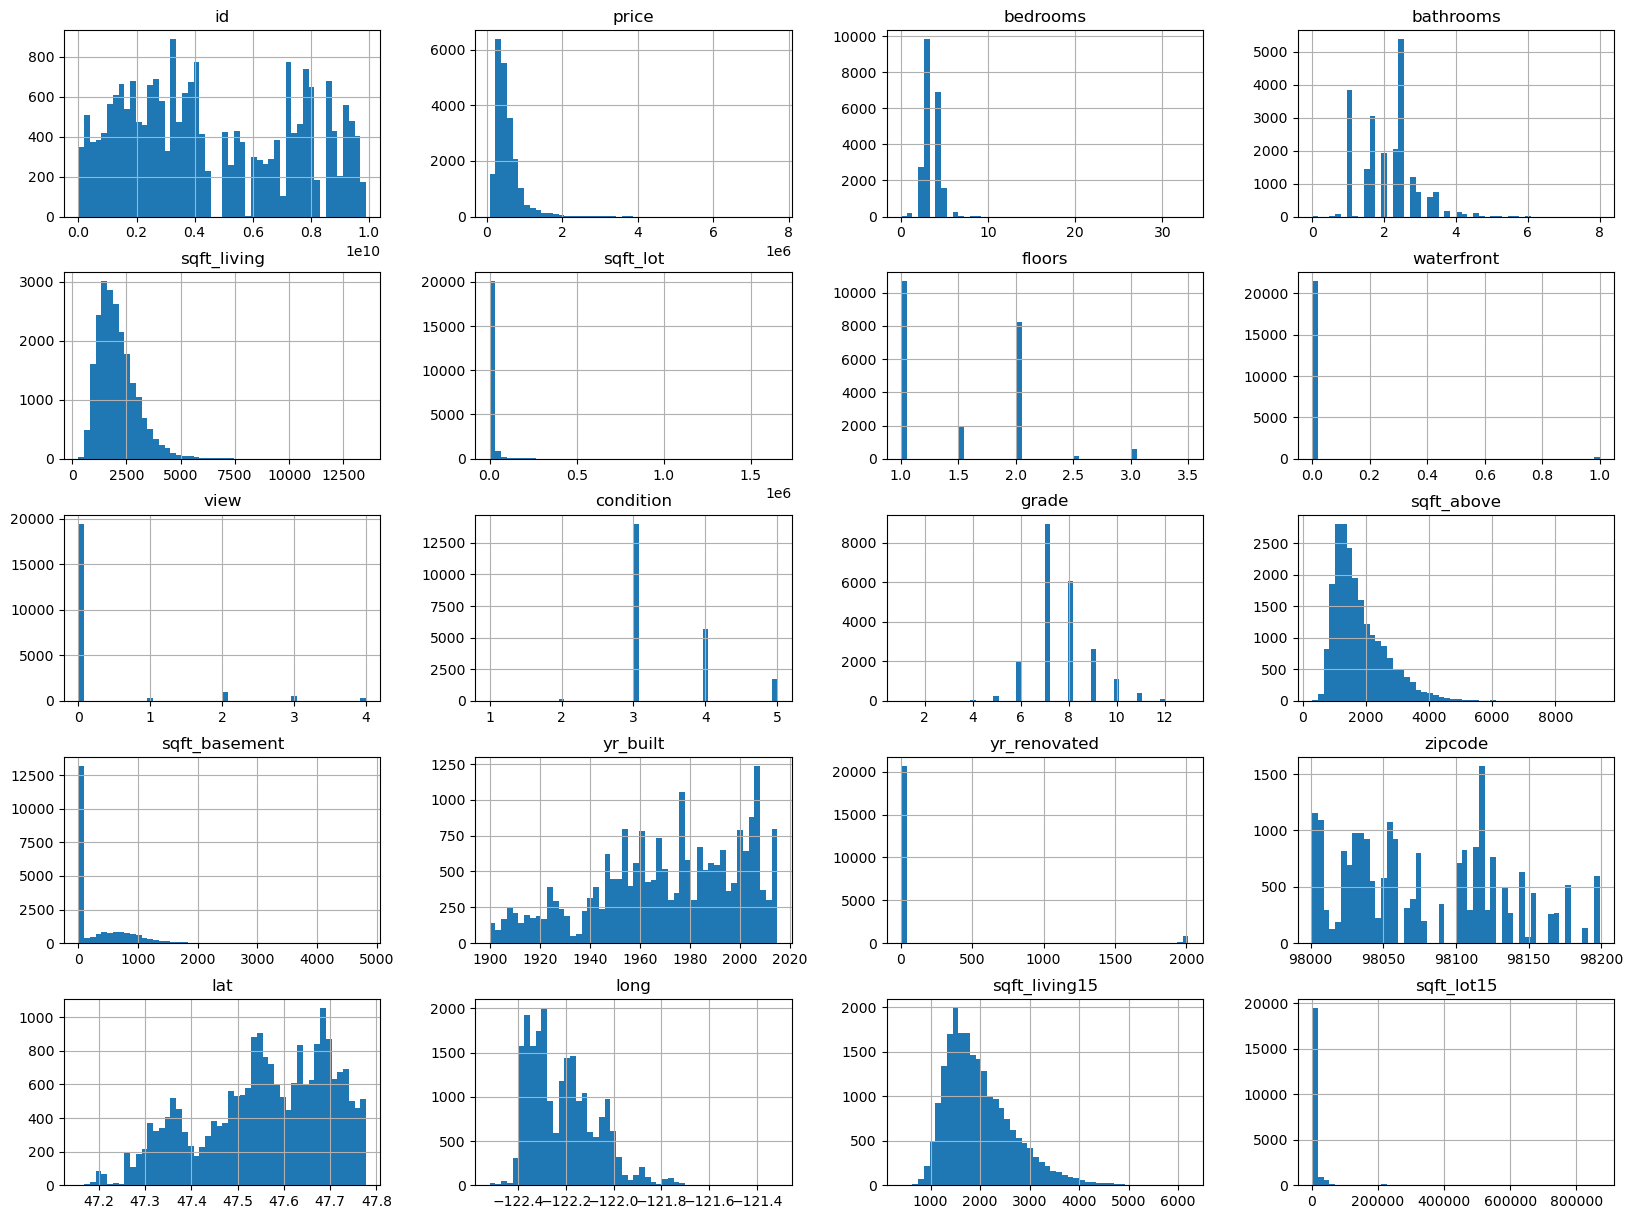

In [49]:
df.hist(bins = 50, figsize=(20,15))
plt.show()

## Step 1 – Data Quality Fixes (on full dataset, before split)

These fixes are applied to the **entire** dataset before the train/test split because they correct
raw data errors and do **not** involve learning any statistics from the data:

| Issue | Action |
|-------|--------|
| No missing values | Nothing to impute |
| 177 duplicate IDs (same house, multiple sales) | Keep most-recent sale only |
| 1 row with 33 bedrooms (data-entry error) | Drop row |
| `date` stored as string | Parse to datetime (needed for dedup sort) |

In [ ]:
#  Null / missing value check 
print("Missing values per column:")
print(df.isnull().sum())
total_missing = df.isnull().sum().sum()
print(f"Total missing: {total_missing}")   # expect 0

Missing values per column:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64
Total missing: 0


In [ ]:
#  Parse date, drop duplicates , remove outlier 
print(f"Rows before cleaning: {len(df)}")

# Convert date string to datetime so we can sort
df["date"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%S")

# Keep only the most-recent sale for each house id
df = df.sort_values("date").drop_duplicates(subset="id", keep="last")

# Drop the 33-bedroom row (data-entry error; all legitimate houses have <20 bedrooms)
df = df[df["bedrooms"] < 20]

print(f"Rows after  cleaning: {len(df)}")

Rows before cleaning: 21613
Rows after  cleaning: 21435


In [52]:
#Splitting the dataset into testing and training dataset
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

housing_train = train_set.copy()
housing_test  = test_set.copy()

print(f"Training size : {len(housing_train)} rows")
print(f"Test size     : {len(housing_test)} rows")

Training size : 17148 rows
Test size     : 4287 rows


In [53]:
from sklearn.base import BaseEstimator, TransformerMixin
class HousingFeatureEngineer(BaseEstimator,TransformerMixin):
    def fit(self, X, y = None):
        return self 
        
    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=['id'])
        X['sale_year']  = X['date'].dt.year
        X['sale_month'] = X['date'].dt.month
        X = X.drop(columns=['date'])
        X['house_age'] = X['sale_year'] - X['yr_built']
        X['renovated'] = (X['yr_renovated'] > 0).astype(int)
        X['yrs_since_renovation'] = np.where(
            X['yr_renovated'] > 0,
            X['sale_year'] - X['yr_renovated'], 0
        )
        X = X.drop(columns=['yr_built', 'yr_renovated'])
        return X

In [54]:
#Build The Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

x_train = housing_train.drop(columns = ['price'])
y_train = housing_train['price']

x_test = housing_test.drop(columns = ['price'])
y_test = housing_test['price']

pipe = Pipeline([
    ('feature_eng', HousingFeatureEngineer()),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
pipe.fit(x_train, y_train)
print("R² score:", pipe.score(x_test, y_test))


R² score: 0.7001681479001185


In [55]:
#Predictions 
some_data = x_test.iloc[:5]
some_labels = y_test.iloc[:5]
predictions = pipe.predict(some_data)

comparison = pd.DataFrame({
    'Actual Price ($)':     some_labels.values,
    'Predicted Price ($)':  predictions.round(0),
    'Error ($)':            (predictions - some_labels.values).round(0),
    'Error (%)':            ((predictions - some_labels.values) / some_labels.values * 100).round(1)
})

print(comparison)






   Actual Price ($)  Predicted Price ($)  Error ($)  Error (%)
0          570000.0             702801.0   132801.0       23.3
1          279000.0             280079.0     1079.0        0.4
2          300000.0             361841.0    61841.0       20.6
3          259000.0             215081.0   -43919.0      -17.0
4          130000.0             134554.0     4554.0        3.5


R²   : 0.7002
MAE  : $127,067   ← average  error
RMSE : $194,452  ← penalises large errors more heavily


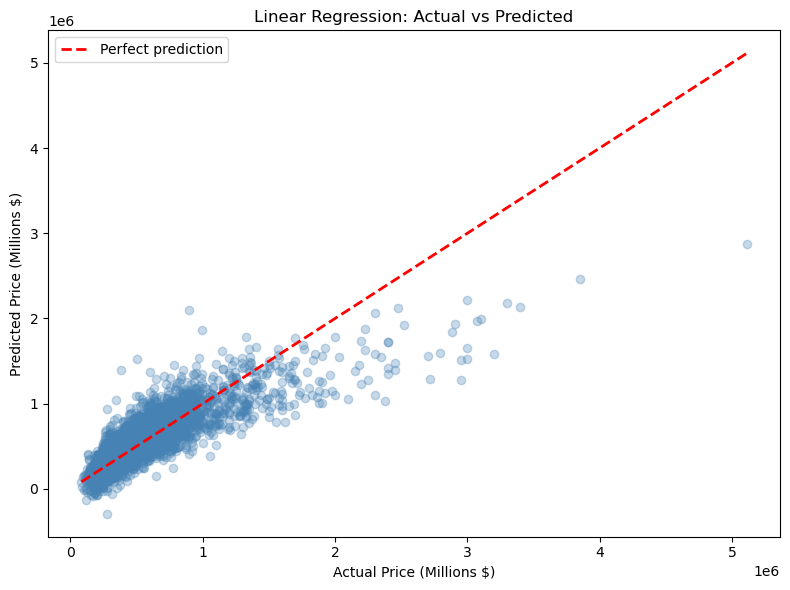

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error 

y_predict = pipe.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))
r2   = pipe.score(x_test, y_test)

print(f"R²   : {r2:.4f}")
print(f"MAE  : ${mae:,.0f}   ← average  error")
print(f"RMSE : ${rmse:,.0f}  ← penalises large errors more heavily")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price (Millions $)')
plt.ylabel('Predicted Price (Millions $)')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()







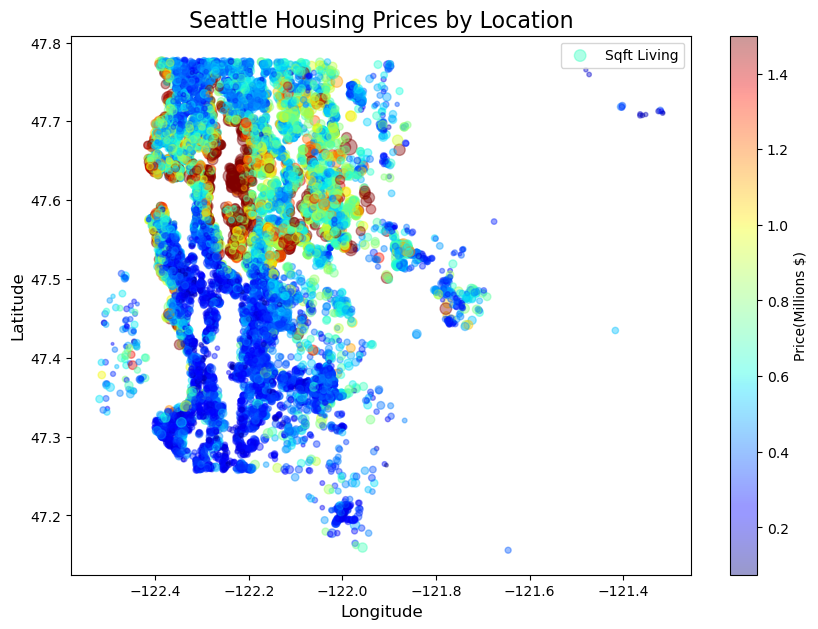

In [42]:
housing_train["Price(Millions $)"] = housing_train["price"] / 1000000
ax = housing_train.plot(kind = "scatter", x = "long", y = "lat", alpha = 0.4,
s = housing_train["sqft_living"]/100, label = "Sqft Living",figsize = (10,7),
c = "Price(Millions $)",cmap = plt.get_cmap("jet"),
colorbar = True,
sharex = False, vmax = 1.5)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("Seattle Housing Prices by Location", fontsize=16)
plt.legend()
plt.show()




In [7]:
corr_matrix = housing_train.corr(numeric_only=True)
print(corr_matrix['price'].sort_values(ascending = False))

price                1.000000
Price(Millions $)    1.000000
sqft_living          0.701700
grade                0.665093
sqft_above           0.603255
sqft_living15        0.582666
bathrooms            0.526616
view                 0.392108
sqft_basement        0.321387
lat                  0.310770
bedrooms             0.308297
floors               0.253424
waterfront           0.252946
yr_renovated         0.127737
sqft_lot             0.091039
sqft_lot15           0.079152
yr_built             0.049099
condition            0.036343
long                 0.023485
id                  -0.020624
zipcode             -0.053800
Name: price, dtype: float64
